In [1]:
import os

# GPU Bellek yönetimini baştan sıkı tutuyoruz
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import shutil
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             cohen_kappa_score, confusion_matrix, 
                             classification_report, roc_curve, auc, 
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize

# --- AYARLAR ---
SEARCH_EPOCHS = 5    
FULL_EPOCHS = 20     
PATIENCE = 3         
BATCH_SIZE = 32    
OUTPUT_DIR = 'alexnet' 

# Klasör temizliği
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

# Tekrar edilebilirlik (Reproducibility)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"AlexNet Projesi Başlatılıyor... Cihaz: {device}")

AlexNet Projesi Başlatılıyor... Cihaz: cuda


In [2]:
# Veri seti yolum
DATA_DIR = r'C:\Users\user\Desktop\DerinProjem\garbage-dataset'

# AlexNet için veri ön işleme (ImageNet standartları)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print(f"\nVeri seti okunuyor: {DATA_DIR}")
try:
    full_dataset = datasets.ImageFolder(DATA_DIR, transform=data_transforms)
    classes = full_dataset.classes
    print(f"Veri seti tamam! Sınıflar: {classes}")
except Exception as e:
    print(f"HATA: Veri setini bulamadım. ({e})")
    full_dataset = datasets.FakeData(size=50, image_size=(3, 224, 224), num_classes=2, transform=data_transforms)
    classes = ['glass', 'paper']

# Train / Val / Test Ayrımı
targets = full_dataset.targets
train_idx, temp_idx = train_test_split(
    range(len(full_dataset)), test_size=0.3, stratify=targets, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=42
)

# DataLoader (Windows için num_workers=0)
train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Shape Kontrolü
img_batch, lbl_batch = next(iter(train_loader))
print(f"\n--- AlexNet Girdi Kontrolü ---")
print(f"Giriş Resmi: {img_batch.shape} (Batch, C, H, W)")


Veri seti okunuyor: C:\Users\user\Desktop\DerinProjem\garbage-dataset
Veri seti tamam! Sınıflar: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']

--- AlexNet Girdi Kontrolü ---
Giriş Resmi: torch.Size([32, 3, 224, 224]) (Batch, C, H, W)


In [3]:
def get_model(num_classes):
    # AlexNet'in güncel ağırlıklarını indiriyoruz
    weights = models.AlexNet_Weights.IMAGENET1K_V1
    model = models.alexnet(weights=weights)
    
    # AlexNet'te classifier bloğunun son katmanı (index 6) değiştirilir
    # Orijinalinde 1000 sınıf var, biz onu kendi çöp sınıf sayımıza düşürüyoruz.
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, num_classes)
    
    return model.to(device)

# Yardımcı Fonksiyonlar (Aynen devam)
def accuracy_topk(output, target, topk=(1,)):
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size).item())
        return res

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader.dataset), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader.dataset), 100. * correct / total

In [4]:
# 5 adet LR adayı (Sabit Seed sayesinde yine aynı adaylar gelecek)
lr_candidates = [10**np.random.uniform(-5, -2) for _ in range(5)]
criterion = nn.CrossEntropyLoss()

best_lr = None
best_val_acc_search = 0.0

print(f"\n=== AŞAMA 1: Random Search (AlexNet - {SEARCH_EPOCHS} Epoch) ===")
print(f"Adaylar: {[f'{lr:.6f}' for lr in lr_candidates]}")

for i, lr in enumerate(lr_candidates):
    print(f"\n>>> Deneme {i+1}/5 | LR: {lr:.6f}")
    
    # Hafıza temizliği
    if 'temp_model' in locals(): del temp_model
    torch.cuda.empty_cache()
    
    temp_model = get_model(len(classes))
    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SEARCH_EPOCHS)
    
    val_acc = 0
    for epoch in range(SEARCH_EPOCHS):
        train_loss, train_acc = train_one_epoch(temp_model, train_loader, criterion, optimizer)
        _, val_acc = validate(temp_model, val_loader, criterion)
        scheduler.step()
        print(f"   Ep {epoch+1}: Loss {train_loss:.3f} | Val Acc %{val_acc:.2f}")
    
    if val_acc > best_val_acc_search:
        best_val_acc_search = val_acc
        best_lr = lr
        print("   --> (!) Yeni en iyi aday bulundu.")

print(f"\n>>> SEÇİLEN LR: {best_lr:.6f}")
del temp_model
torch.cuda.empty_cache()


=== AŞAMA 1: Random Search (AlexNet - 5 Epoch) ===
Adaylar: ['0.000133', '0.007114', '0.001570', '0.000625', '0.000029']

>>> Deneme 1/5 | LR: 0.000133


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\user/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|███████████████████████████████████████████████████████████████████████████████| 233M/233M [00:17<00:00, 13.9MB/s]
C:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


   Ep 1: Loss 0.532 | Val Acc %88.70
   Ep 2: Loss 0.240 | Val Acc %89.81
   Ep 3: Loss 0.109 | Val Acc %92.14
   Ep 4: Loss 0.035 | Val Acc %93.15
   Ep 5: Loss 0.014 | Val Acc %93.35
   --> (!) Yeni en iyi aday bulundu.

>>> Deneme 2/5 | LR: 0.007114
   Ep 1: Loss 40.119 | Val Acc %26.96
   Ep 2: Loss 2.132 | Val Acc %26.96
   Ep 3: Loss 25.931 | Val Acc %26.96
   Ep 4: Loss 2.161 | Val Acc %26.96
   Ep 5: Loss 2.128 | Val Acc %26.96

>>> Deneme 3/5 | LR: 0.001570
   Ep 1: Loss 2.201 | Val Acc %26.96
   Ep 2: Loss 2.135 | Val Acc %26.96
   Ep 3: Loss 2.131 | Val Acc %26.96
   Ep 4: Loss 2.130 | Val Acc %26.96
   Ep 5: Loss 2.129 | Val Acc %26.96

>>> Deneme 4/5 | LR: 0.000625
   Ep 1: Loss 1.043 | Val Acc %73.65
   Ep 2: Loss 0.741 | Val Acc %78.51
   Ep 3: Loss 0.498 | Val Acc %84.35
   Ep 4: Loss 0.265 | Val Acc %88.02
   Ep 5: Loss 0.109 | Val Acc %90.28

>>> Deneme 5/5 | LR: 0.000029
   Ep 1: Loss 0.596 | Val Acc %89.14
   Ep 2: Loss 0.247 | Val Acc %91.57
   Ep 3: Loss 0.139 | V

In [5]:
print(f"\n=== AŞAMA 2: Full Training ({FULL_EPOCHS} Epoch) ===")

final_model = get_model(len(classes))
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FULL_EPOCHS)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_full_acc = 0.0
patience_counter = 0

for epoch in range(FULL_EPOCHS):
    train_loss, train_acc = train_one_epoch(final_model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(final_model, val_loader, criterion)
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc / 100.0)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc / 100.0)
    
    print(f"Epoch {epoch+1}/{FULL_EPOCHS} | Val Acc: %{val_acc:.2f}")
    
    if val_acc > best_full_acc:
        best_full_acc = val_acc
        torch.save(final_model.state_dict(), os.path.join(OUTPUT_DIR, 'alexnet_best_model.pth'))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"   --> Erken durdurma (Patience={PATIENCE})")
            break

final_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'alexnet_best_model.pth')))
print("AlexNet eğitimi tamamlandı.")


=== AŞAMA 2: Full Training (20 Epoch) ===
Epoch 1/20 | Val Acc: %87.08
Epoch 2/20 | Val Acc: %90.86
Epoch 3/20 | Val Acc: %89.27
Epoch 4/20 | Val Acc: %90.89
Epoch 5/20 | Val Acc: %91.70
Epoch 6/20 | Val Acc: %91.09
Epoch 7/20 | Val Acc: %92.38
Epoch 8/20 | Val Acc: %91.46
Epoch 9/20 | Val Acc: %92.51
Epoch 10/20 | Val Acc: %91.80
Epoch 11/20 | Val Acc: %92.88
Epoch 12/20 | Val Acc: %93.18
Epoch 13/20 | Val Acc: %93.32
Epoch 14/20 | Val Acc: %93.49
Epoch 15/20 | Val Acc: %93.59
Epoch 16/20 | Val Acc: %93.35
Epoch 17/20 | Val Acc: %93.52
Epoch 18/20 | Val Acc: %93.72
Epoch 19/20 | Val Acc: %93.76
Epoch 20/20 | Val Acc: %93.83


C:\Users\user\AppData\Local\Temp\ipykernel_24272\490796905.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(os.path.join(OUTPUT_DI

AlexNet eğitimi tamamlandı.


In [6]:
print("\n=== Performans Raporu ===")
final_model.eval()

y_true, y_pred, y_score = [], [], []
top1_sum, topk_sum = 0, 0
total_samples = 0
k_val = min(5, len(classes))

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(torch.max(probs, 1)[1].cpu().numpy())
        y_score.extend(probs.cpu().numpy())
        
        res = accuracy_topk(outputs, labels, topk=(1, k_val))
        batch_num = labels.size(0)
        top1_sum += res[0] * batch_num / 100.0
        topk_sum += res[1] * batch_num / 100.0
        total_samples += batch_num

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

# Metrik Hesapları
acc_top1 = (top1_sum / total_samples) * 100
acc_topk = (topk_sum / total_samples) * 100
kappa = cohen_kappa_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

y_true_bin = label_binarize(y_true, classes=range(len(classes)))
try:
    if len(classes) > 2 and y_true_bin.shape[1] == y_score.shape[1]:
        roc_auc_macro = roc_auc_score(y_true_bin, y_score, average='macro', multi_class='ovr')
    else:
        roc_auc_macro = 0.0
except: roc_auc_macro = 0.0

# CSV Kayıtları
df_general = pd.DataFrame({
    'Model': ['AlexNet'],
    'Top-1 Acc': [f"%{acc_top1:.2f}"],
    f'Top-{k_val} Acc': [f"%{acc_topk:.2f}"],
    'Macro F1': [f"{macro_f1:.4f}"],
    'ROC AUC': [f"{roc_auc_macro:.4f}"],
    'Kappa': [f"{kappa:.4f}"]
})
df_general.to_csv(os.path.join(OUTPUT_DIR, 'Genel_Performans.csv'), index=False)

report_dict = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
df_classes = pd.DataFrame(report_dict).transpose().iloc[:-3, :3]
df_classes.to_csv(os.path.join(OUTPUT_DIR, 'Sinif_Bazli_Performans.csv'))
print("Tablolar oluşturuldu.")


=== Performans Raporu ===
Tablolar oluşturuldu.


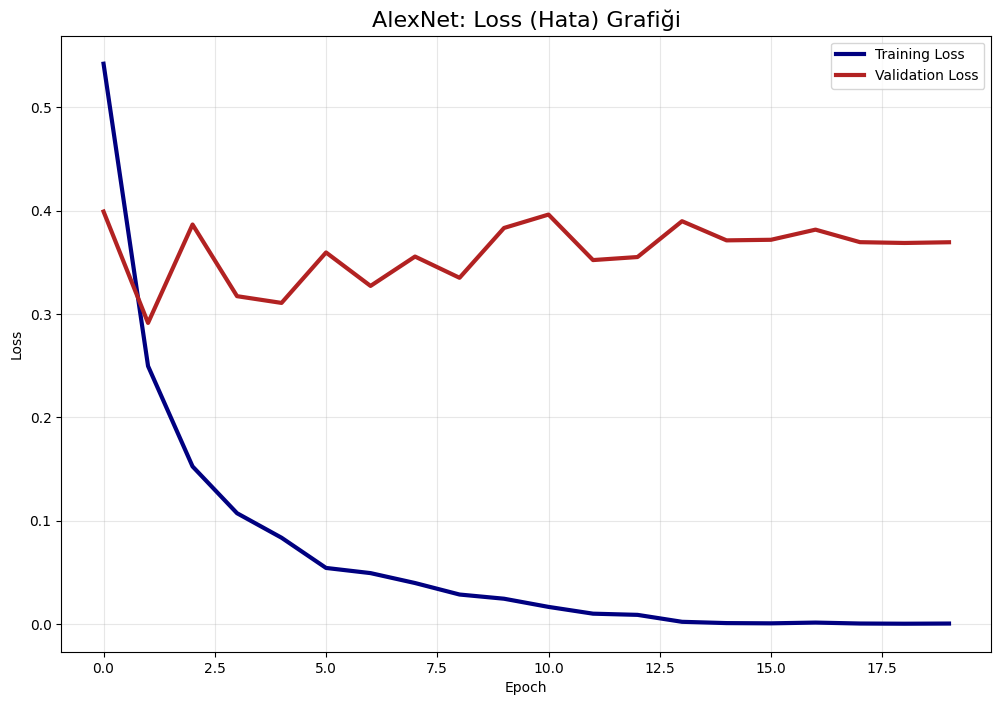

In [7]:
plt.figure(figsize=(12, 8))
plt.plot(history['train_loss'], label='Training Loss', color='navy', linewidth=3)
plt.plot(history['val_loss'], label='Validation Loss', color='firebrick', linewidth=3)
plt.title('AlexNet: Loss (Hata) Grafiği', fontsize=16)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_1_Loss.png'))
plt.show()

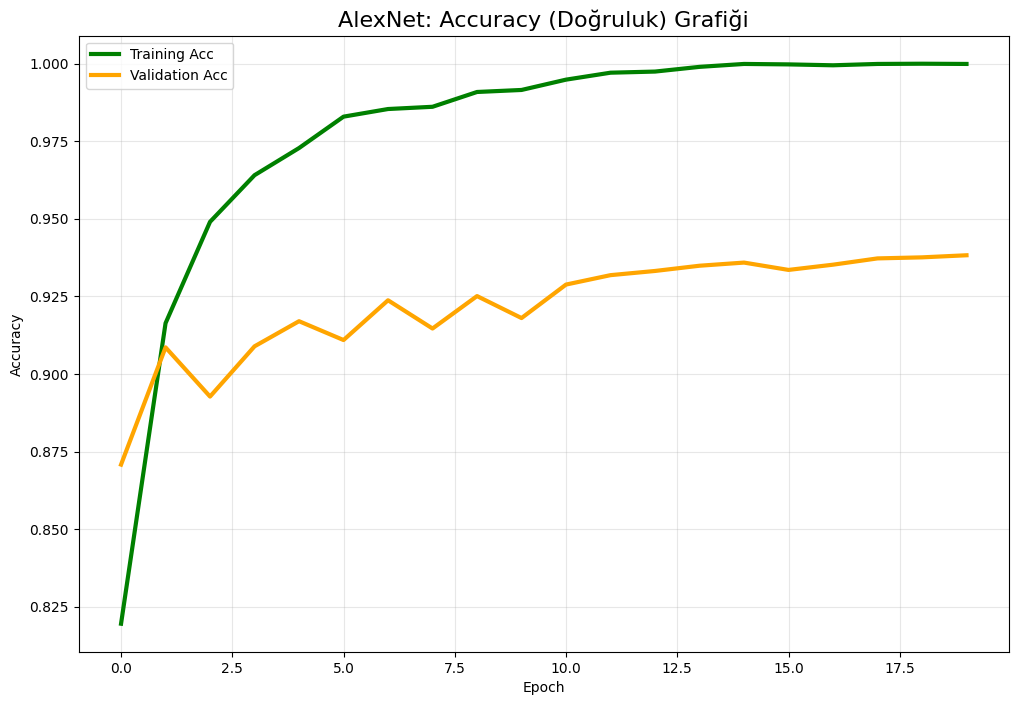

In [8]:
plt.figure(figsize=(12, 8))
plt.plot(history['train_acc'], label='Training Acc', color='green', linewidth=3)
plt.plot(history['val_acc'], label='Validation Acc', color='orange', linewidth=3)
plt.title('AlexNet: Accuracy (Doğruluk) Grafiği', fontsize=16)
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_2_Accuracy.png'))
plt.show()

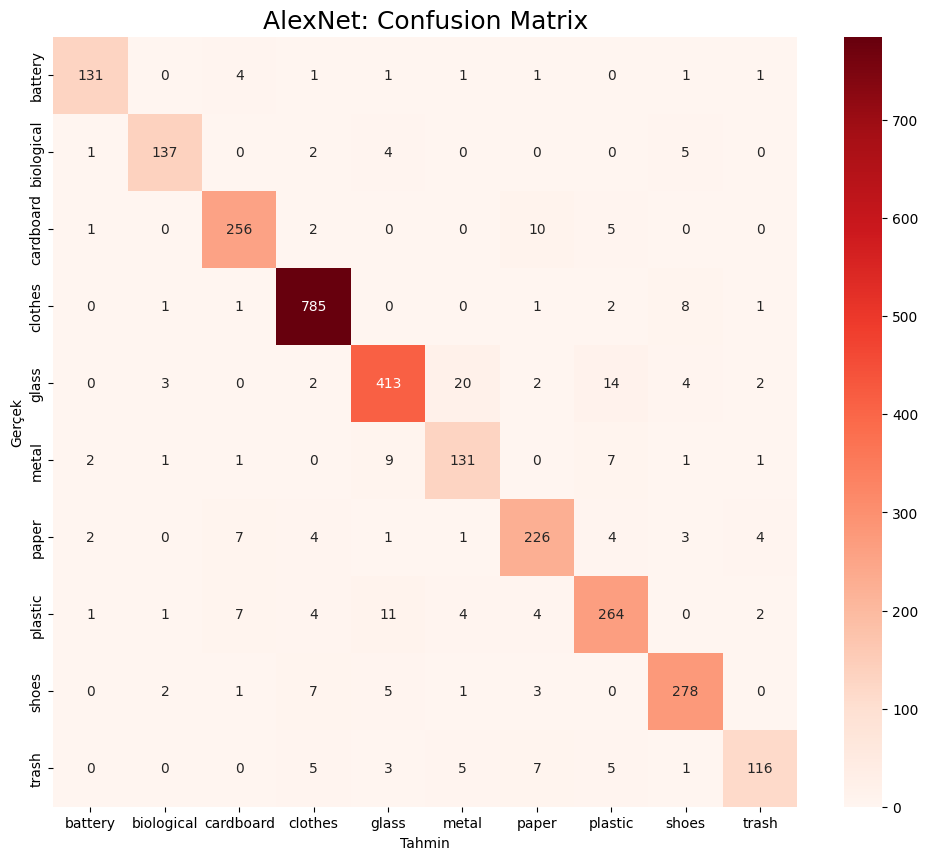

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=classes, yticklabels=classes)
plt.title('AlexNet: Confusion Matrix', fontsize=18)
plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_3_Confusion.png'))
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_24272\2203640516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_classes.index, y=df_classes['f1-score'], palette='magma')


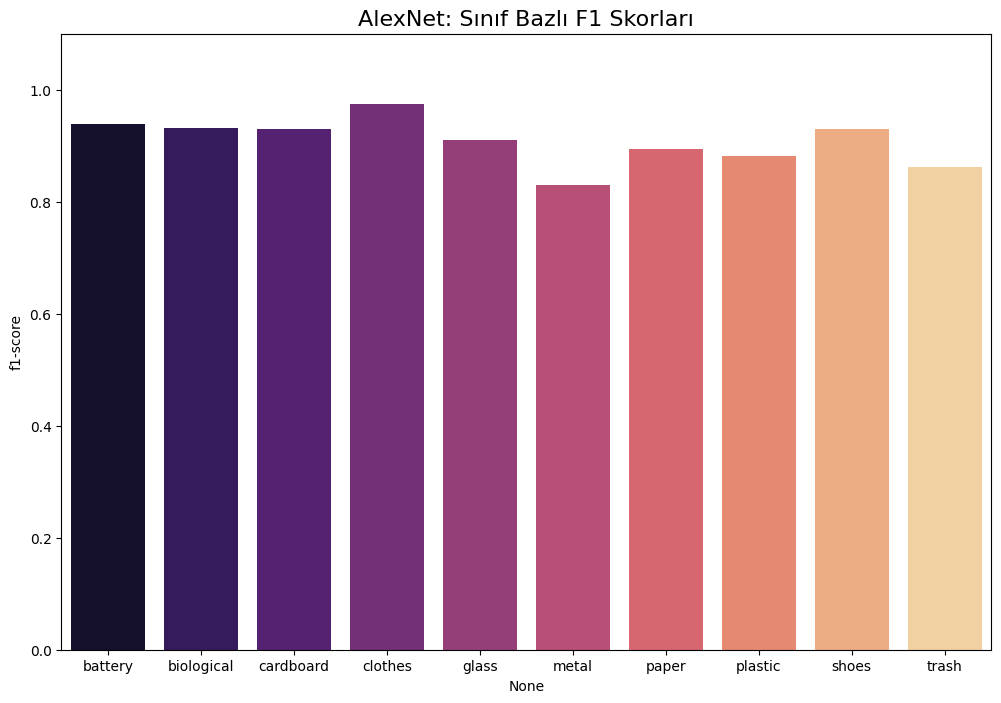

In [10]:
plt.figure(figsize=(12, 8))
sns.barplot(x=df_classes.index, y=df_classes['f1-score'], palette='magma')
plt.title('AlexNet: Sınıf Bazlı F1 Skorları', fontsize=16)
plt.ylim(0, 1.1)
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_4_F1_Bar.png'))
plt.show()

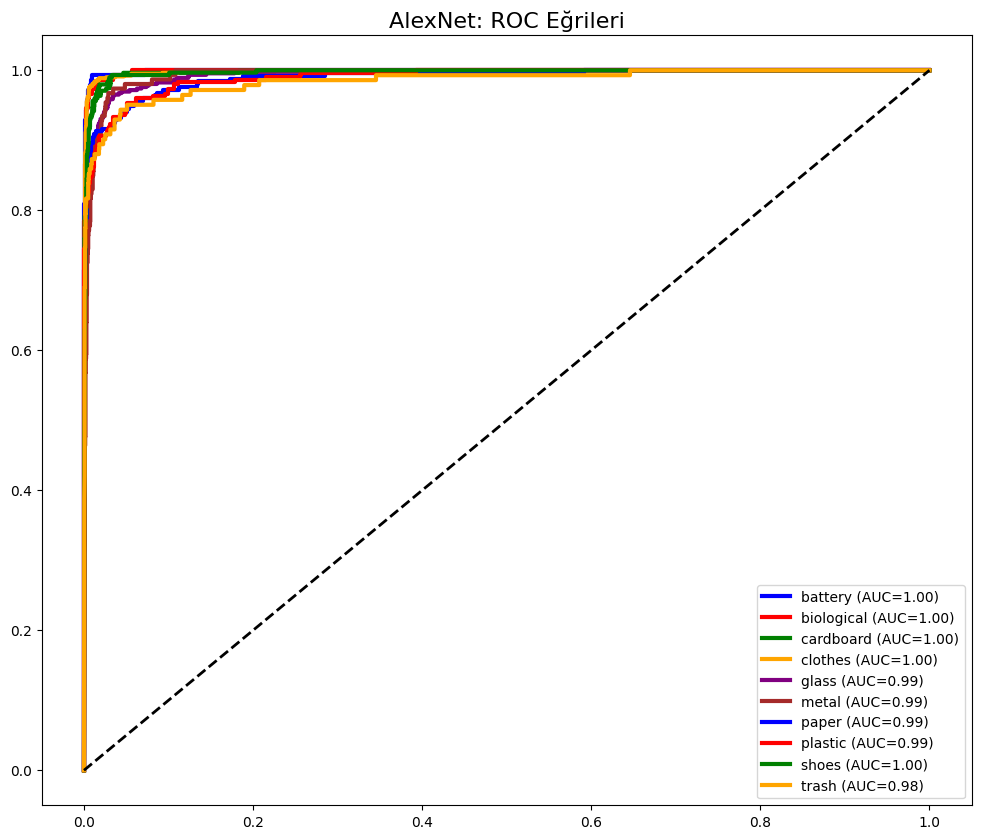

In [11]:
plt.figure(figsize=(12, 10))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, c in zip(range(len(classes)), colors):
    if i < y_true_bin.shape[1]:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=c, lw=3, label=f'{classes[i]} (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('AlexNet: ROC Eğrileri', fontsize=16)
plt.legend(loc="lower right")
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_5_ROC.png'))
plt.show()

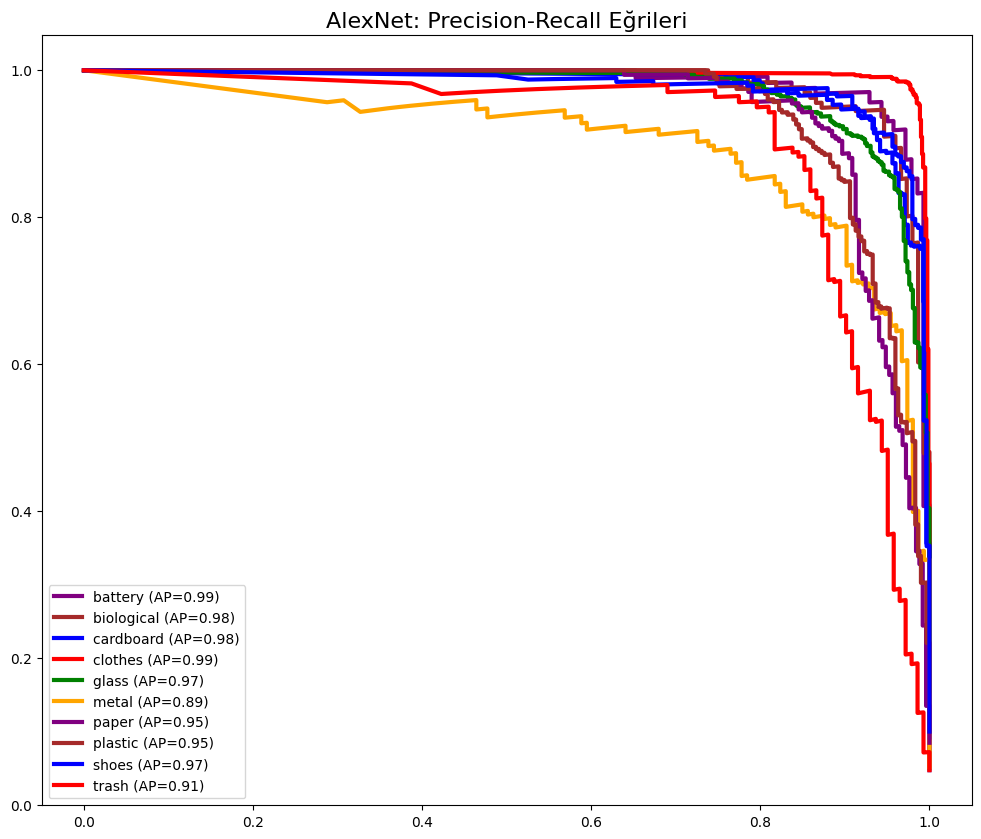

In [12]:
plt.figure(figsize=(12, 10))
for i, c in zip(range(len(classes)), colors):
    if i < y_true_bin.shape[1]:
        p, r, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
        plt.plot(r, p, color=c, lw=3, label=f'{classes[i]} (AP={ap:.2f})')
plt.title('AlexNet: Precision-Recall Eğrileri', fontsize=16)
plt.legend(loc="lower left")
plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_6_PR.png'))
plt.show()

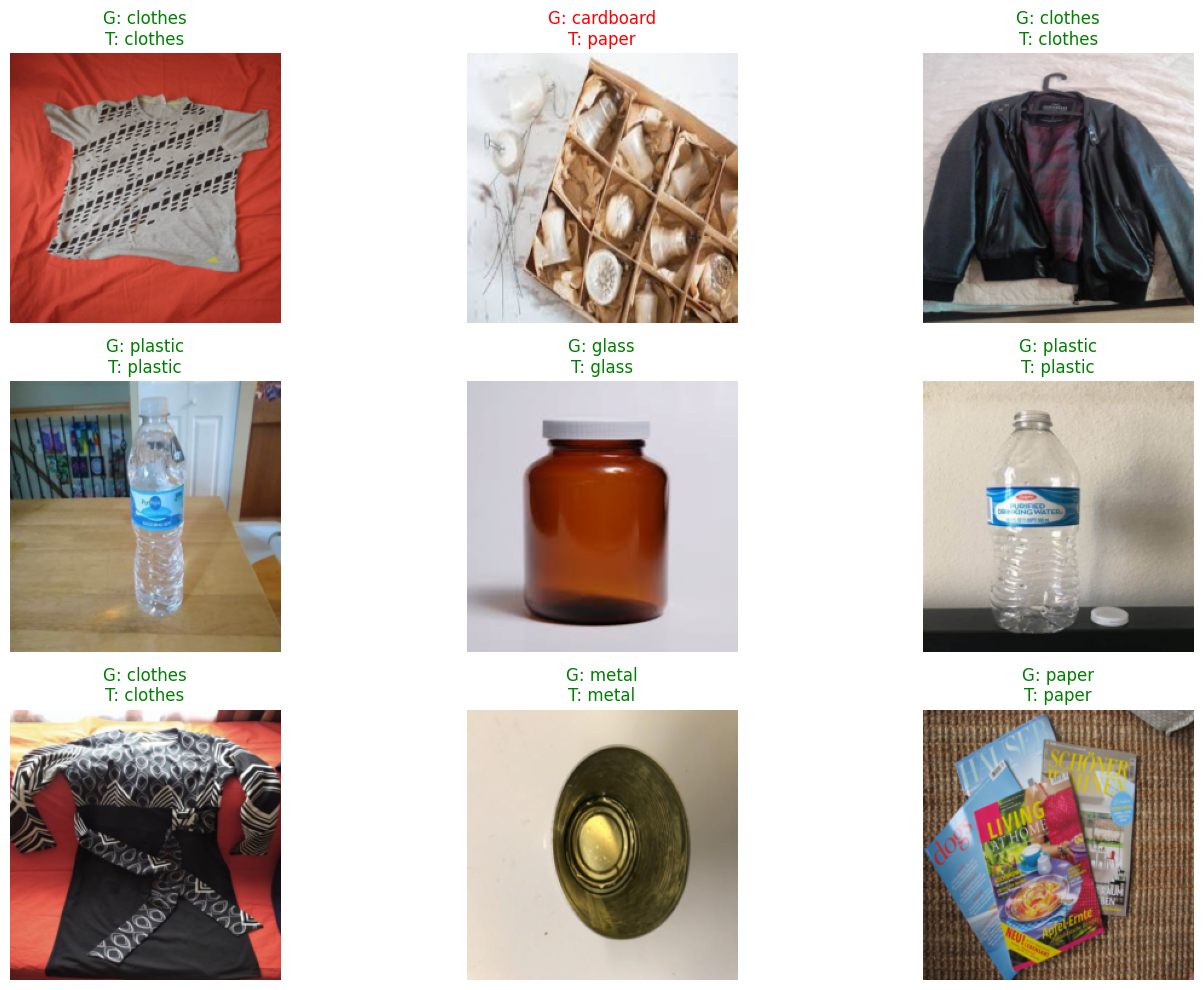

In [13]:
def visualize_preds(model, loader):
    model.eval()
    plt.figure(figsize=(15, 10))
    images_shown = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for j in range(inputs.size(0)):
                if images_shown >= 9: break
                ax = plt.subplot(3, 3, images_shown+1)
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                img = np.clip(np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]), 0, 1)
                col = 'green' if preds[j] == labels[j] else 'red'
                ax.set_title(f"G: {classes[labels[j]]}\nT: {classes[preds[j]]}", color=col, fontsize=12)
                ax.imshow(img); ax.axis('off')
                images_shown += 1
            if images_shown >= 9: break
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_7_Tahminler.png'))
    plt.show()

visualize_preds(final_model, test_loader)

In [14]:
shutil.make_archive('alexnet', 'zip', OUTPUT_DIR)
print(f"\n✅ AlexNet projesi tamamlandı! '{OUTPUT_DIR}' klasörü ve zip dosyası hazır.")
print(f"Zip Yolu: {os.getcwd()}\\alexnet.zip")


✅ AlexNet projesi tamamlandı! 'alexnet' klasörü ve zip dosyası hazır.
Zip Yolu: C:\Users\user\Desktop\DerinProjem\alexnet.zip


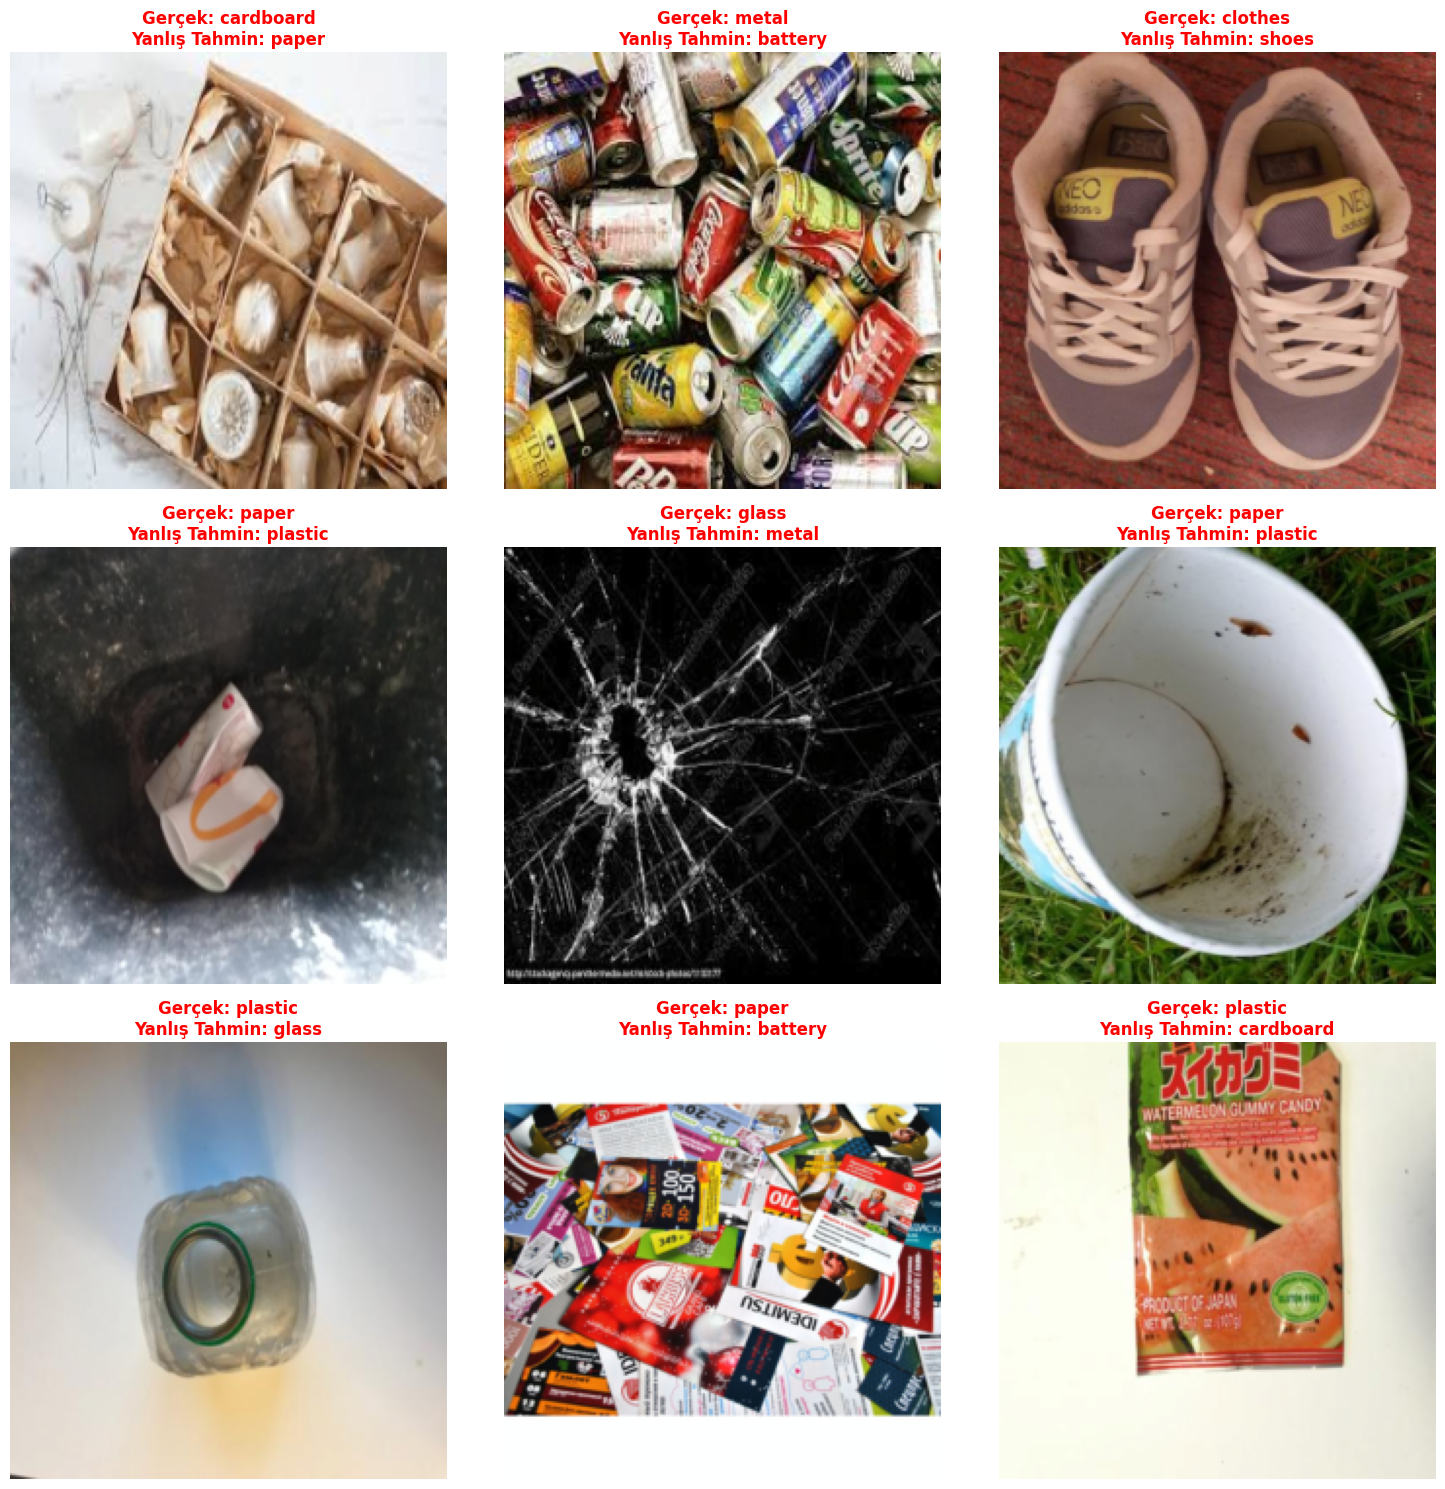

In [17]:
#modelin yanlış bildiklerine bakıpimport matplotlib.pyplot as plt
import numpy as np
import torch
import os

def visualize_mistakes(model, loader, count=9):
    model.eval()
    plt.figure(figsize=(15, 15))
    
    
    mistakes_shown = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            # --- DÜZELTME BURADA ---
            inputs = inputs.to(device)
            labels = labels.to(device) # <--- EKSİK OLAN SATIR BUYDU
            # -----------------------
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            # Sadece hatalı olanları filtrele
            mistake_mask = preds != labels
            
            # Eğer bu batch'te hata yoksa geç
            if not mistake_mask.any():
                continue
                
            # Hatalı olanları seç
            wrong_inputs = inputs[mistake_mask]
            wrong_labels = labels[mistake_mask]
            wrong_preds = preds[mistake_mask]
            
            for j in range(wrong_inputs.size(0)):
                if mistakes_shown >= count: break
                
                ax = plt.subplot(3, 3, mistakes_shown+1)
                
                # Resmi göster (CPU'ya alıp numpy'a çeviriyoruz)
                img = wrong_inputs[j].cpu().numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = np.clip(std * img + mean, 0, 1)
                
                true_cls = classes[wrong_labels[j]]
                pred_cls = classes[wrong_preds[j]]
                
                # Başlık: Gerçek (Doğru) -> Tahmin (Yanlış)
                ax.set_title(f"Gerçek: {true_cls}\nYanlış Tahmin: {pred_cls}", color='red', fontsize=12, fontweight='bold')
                ax.imshow(img); ax.axis('off')
                mistakes_shown += 1
                
            if mistakes_shown >= count: break

    if mistakes_shown == 0:
        print("Tebrikler! Model test setindeki tüm örnekleri doğru bildi (Hiç hata yok).")
    else:
        plt.tight_layout()
        # Eğer OUTPUT_DIR tanımlı değilse hata vermesin diye kontrol
        if 'OUTPUT_DIR' in globals():
            plt.savefig(os.path.join(OUTPUT_DIR, 'Grafik_Hatalar.png'))
        plt.show()

# Fonksiyonu çalıştır
visualize_mistakes(final_model, test_loader)